# Performing Exploraratory Data Analysis on Sales data
---
- Target Variable: `Profit`
- Goal: To understand `Profit` w.r.t other variables

## Importing Modules

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the data

In [42]:
df = pd.read_csv("data/Superstore.csv", encoding = 'windows-1252')

In [43]:
pd.set_option("display.max_columns", None)

## Understanding the data

In [58]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [45]:
df.shape

(9994, 21)

In [46]:
print(f"Rows:     {df.shape[0]}")
print(f"Columns:  {df.shape[1]}")

Rows:     9994
Columns:  21


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [49]:
df.describe(include="object").T

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_25552\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Order Date,9994,1237,9/5/2016,38
Ship Date,9994,1334,12/16/2015,35
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001


### Observations from this stage:
---

- There are no data missing, all values are non-null: from `df.info()`
- Numeric Columns are stored as str: Order ID, Customer ID, Product ID because of str prefix
- Date Columns stored as str: Order Date, Ship Date
- Customer ID and Customer Name is the same
- All Orders are from only One country: United States


## Inspecting Missing Data

Although it is known from `df.info()` there are no missing values, just as a programming practice

In [50]:
missing = df.isnull().sum()


In [51]:
missing_table = pd.DataFrame({
    "missing_count" : missing,
    "missing_pct" : (missing / len(df)) * 100,
    "missing_dtype" : df.dtypes
})

In [52]:
missing_table = missing_table[missing_table["missing_count"] > 0]
print(missing_table)

Empty DataFrame
Columns: [missing_count, missing_pct, missing_dtype]
Index: []


In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

### Observation from `nunique`
- Row ID: gives no information about the data
- Customer ID and Customer name are the same


In [ ]:
cols_to_drop = [col for col in df.columns if df[col].nunique() in (1,len(df))]

print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)


['Row ID', 'Country']


In [68]:
df.drop(columns= ["Customer ID"], inplace=True)

In [69]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Target Variable Analysis `Profit`

---
- Data Type: Float
- No missing values

In [75]:
print(f"Mean: {df["Profit"].mean()}")
print(f"Median: {df["Profit"].median()}")
print(f"Skew : {df["Profit"].skew()}")

Mean: 28.65689630778467
Median: 8.6665
Skew : 7.561431562468341


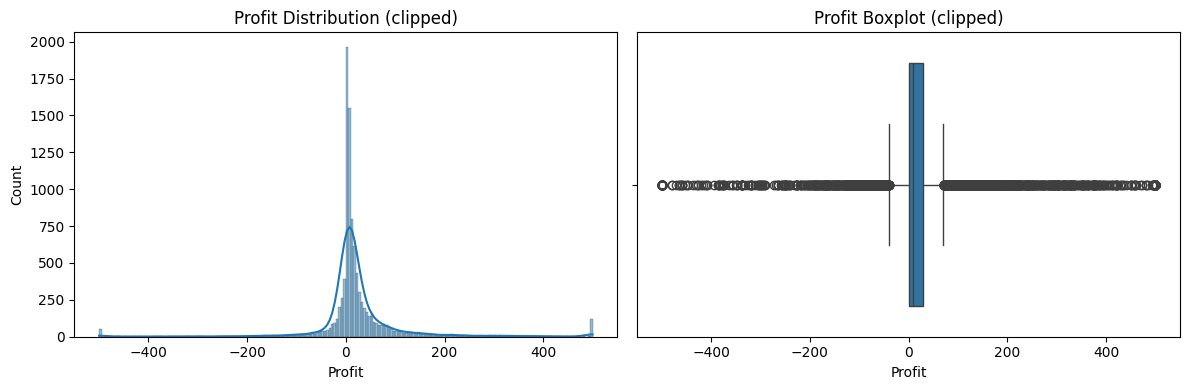

In [117]:
"""fig, axes = plt.subplots(1,2, figsize = (12,8))

sns.histplot(df["Profit"], kde=True, ax = axes[0], line_kws={"color" : "Red"})
axes[0].set_title("Profit Distribution")

sns.boxplot(x = df["Profit"], ax = axes[1])
axes[1].set_title("Profit Boxplot")

plt.tight_layout()
plt.show()"""


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clipped = df["Profit"].clip(-500, 500)

sns.histplot(clipped, kde=True, ax=axes[0], line_kws={"color": "red"})
axes[0].set_title("Profit Distribution (clipped)")

sns.boxplot(x=clipped, ax=axes[1])
axes[1].set_title("Profit Boxplot (clipped)")

plt.tight_layout()
plt.show()

In [123]:
loss_making_sales = df[df["Profit"]<0]
loss_making_sales_pct = len(loss_making_sales) / len(df) *100

print(loss_making_sales["Profit"].sum())
print("Loss Making Sales Percentage: ", loss_making_sales_pct)


-156131.2857
Loss Making Sales Percentage:  18.721232739643785


In [124]:
df[df["Profit"]<0].groupby("Category")["Profit"].count().sort_values()
df[df["Profit"]<0].groupby("Category")["Profit"].sum().sort_values()

Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

In [122]:
profit = df["Profit"].sum()
sales =df["Sales"].sum()

profit_margin = (profit/sales) * 100


print(sales)
print(profit)
print(f"Profit Margin {profit_margin:.2f}%")

2297200.8603
286397.0217
Profit Margin 12.47%
